# Customer Intelligence System
## Country-Level Analysis with Classification, Ensemble Learning & Clustering

**Overview:** End-to-end analysis treating countries as "customers" — predicting development status using ensemble methods (Random Forest, XGBoost) and segmenting via K-Means & DBSCAN clustering.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score,
    roc_auc_score, roc_curve, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

sns.set_theme(style='whitegrid', palette='viridis')
np.random.seed(42)
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"XGBoost available: {XGB_AVAILABLE}")
print(f"Output directory: {OUTPUT_DIR}/")

XGBoost available: True
Output directory: output/


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('Country-data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [5]:
# Check for missing values
print(df.isnull().sum().to_string())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0


## 3. Feature Engineering & Target Creation

In [6]:
X = df.drop(columns=['country'])
country_names = df['country'].values

# Target: Developed (1) vs Developing (0) based on GDPP median
gdpp_median = X['gdpp'].median()
X['developed'] = (X['gdpp'] >= gdpp_median).astype(int)

print(f"GDP per capita median: {gdpp_median:,.0f}")
print(f"Developed countries (gdpp >= median): {X['developed'].sum()}")
print(f"Developing countries (gdpp < median):  {(X['developed'] == 0).sum()}")

# Feature: health spending ratio relative to GDP
X['health_ratio'] = X['health'] / (X['gdpp'] / 1000)

GDP per capita median: 4,660
Developed countries (gdpp >= median): 84
Developing countries (gdpp < median):  83


## 4. Classification — Predicting Development Status

In [7]:
y = X.pop('developed')
feature_names = X.columns.tolist()
print(f"Features: {feature_names}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_scaled, y, np.arange(len(y)), test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Features: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'health_ratio']
Train: 125 | Test: 42


In [8]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5, random_state=42
    ),
}

if XGB_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', verbosity=0
    )
    models['Ensemble (RF+XGB)'] = VotingClassifier(
        estimators=[('rf', models['Random Forest']), ('xgb', models['XGBoost'])],
        voting='soft'
    )

print(f"Models to train: {list(models.keys())}")

Models to train: ['Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble (RF+XGB)']


In [9]:
# Train & evaluate
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'AUC-ROC': auc,
        'CV Mean Acc': cv_scores.mean(), 'CV Std Acc': cv_scores.std()
    })

    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    print(f"  CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(classification_report(y_test, y_pred, target_names=['Developing','Developed']))


Logistic Regression:
  Accuracy:  0.8571 | Precision: 0.8571 | Recall: 0.8571 | F1: 0.8571 | AUC: 0.9637
  CV: 0.9200 ± 0.0358
              precision    recall  f1-score   support

  Developing       0.86      0.86      0.86        21
   Developed       0.86      0.86      0.86        21

    accuracy                           0.86        42
   macro avg       0.86      0.86      0.86        42
weighted avg       0.86      0.86      0.86        42




Random Forest:
  Accuracy:  1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | AUC: 1.0000
  CV: 0.9600 ± 0.0506
              precision    recall  f1-score   support

  Developing       1.00      1.00      1.00        21
   Developed       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42




XGBoost:
  Accuracy:  1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | AUC: 1.0000
  CV: 0.9760 ± 0.0480
              precision    recall  f1-score   support

  Developing       1.00      1.00      1.00        21
   Developed       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42




Ensemble (RF+XGB):
  Accuracy:  1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | AUC: 1.0000
  CV: 0.9760 ± 0.0480
              precision    recall  f1-score   support

  Developing       1.00      1.00      1.00        21
   Developed       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



In [10]:
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV Mean Acc,CV Std Acc
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,0.960,0.050596
2,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,0.976,0.048000
3,Ensemble (RF+XGB),1.000000,1.000000,1.000000,1.000000,1.000000,0.976,0.048000
0,Logistic Regression,0.857143,0.857143,0.857143,0.857143,0.963719,0.920,0.035777


## 5. Feature Importance

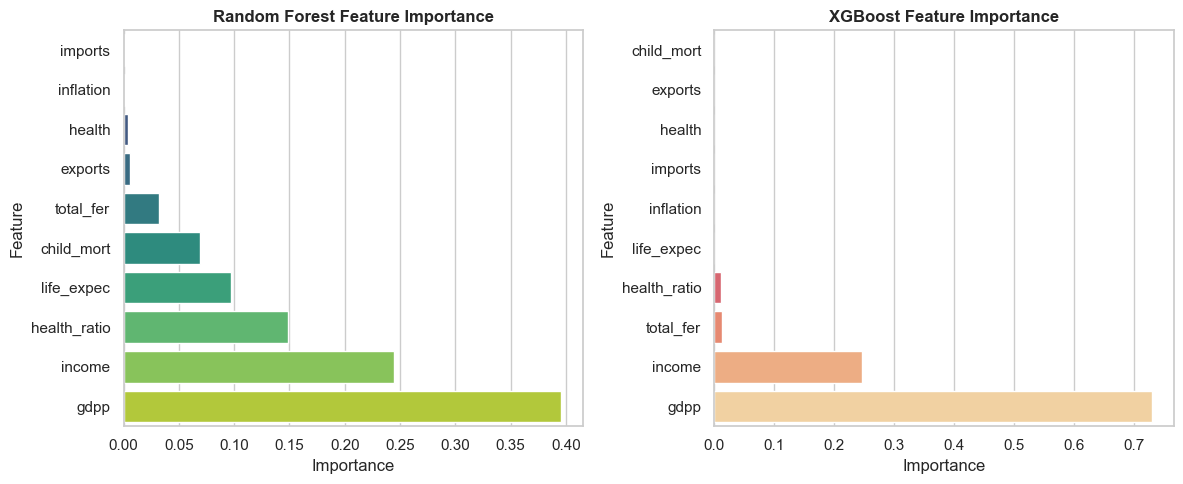

Saved: output/feature_importance.png


In [11]:
fig, axes = plt.subplots(1, 2 if XGB_AVAILABLE else 1, figsize=(12, 5))
axes_list = [axes] if not XGB_AVAILABLE else axes

# Random Forest
rf_model = models['Random Forest']
rf_imp = pd.DataFrame({
    'Feature': feature_names, 'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

ax = axes_list[0]
sns.barplot(data=rf_imp, y='Feature', x='Importance', ax=ax, hue='Feature', palette='viridis', legend=False)
ax.set_title('Random Forest Feature Importance', fontweight='bold')

if XGB_AVAILABLE:
    xgb_model = models['XGBoost']
    xgb_imp = pd.DataFrame({
        'Feature': feature_names, 'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    ax2 = axes_list[1]
    sns.barplot(data=xgb_imp, y='Feature', x='Importance', ax=ax2, hue='Feature', palette='magma', legend=False)
    ax2.set_title('XGBoost Feature Importance', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/feature_importance.png")

## 6. ROC Curves

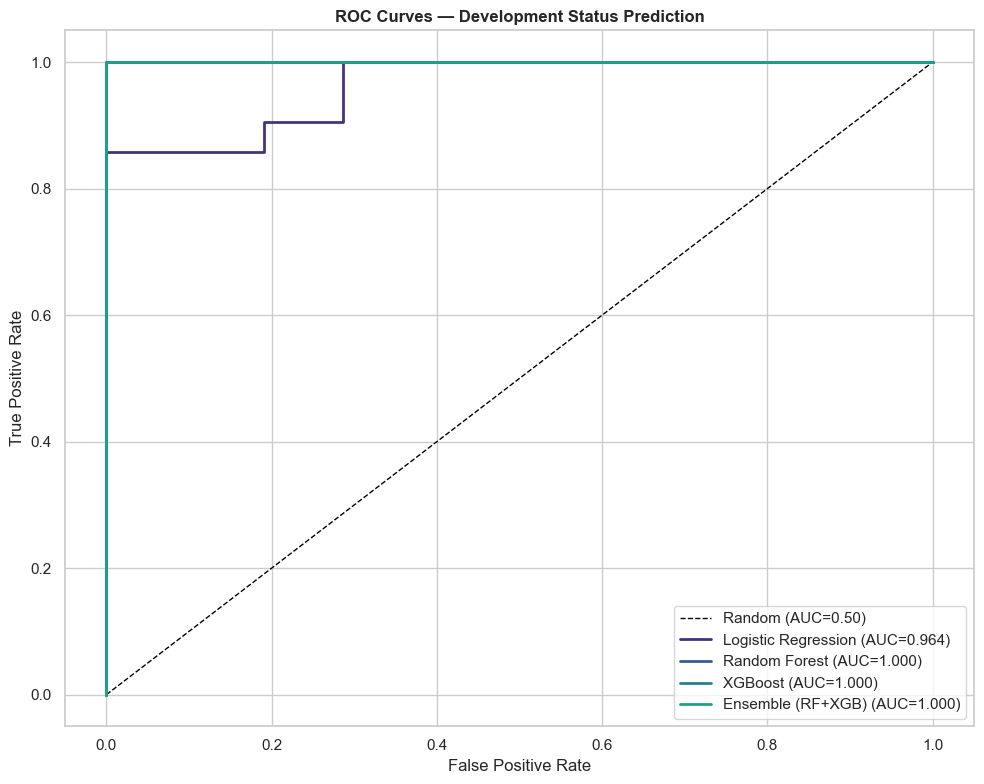

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.50)')

for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble (RF+XGB)']:
    if name not in models:
        continue
    y_prob = models[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Development Status Prediction', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Clustering — Customer (Country) Segmentation

### 7a. K-Means — Optimal k Selection

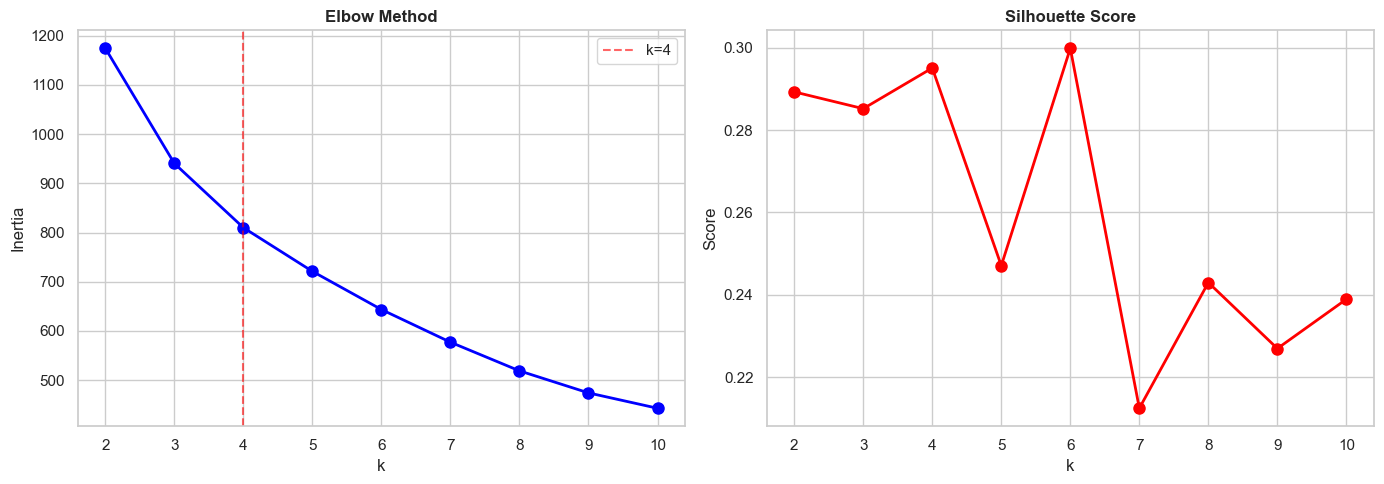

In [13]:
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Fit K-Means with k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, kmeans_labels)
db = davies_bouldin_score(X_scaled, kmeans_labels)
ch = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"K-Means (k={optimal_k}):")
print(f"  Silhouette Score:      {sil:.4f}")
print(f"  Davies-Bouldin Index:  {db:.4f}")
print(f"  Calinski-Harabasz:     {ch:.4f}")

K-Means (k=4):
  Silhouette Score:      0.2951
  Davies-Bouldin Index:  1.0529
  Calinski-Harabasz:     57.7026


### 7b. DBSCAN — Density-Based Clustering

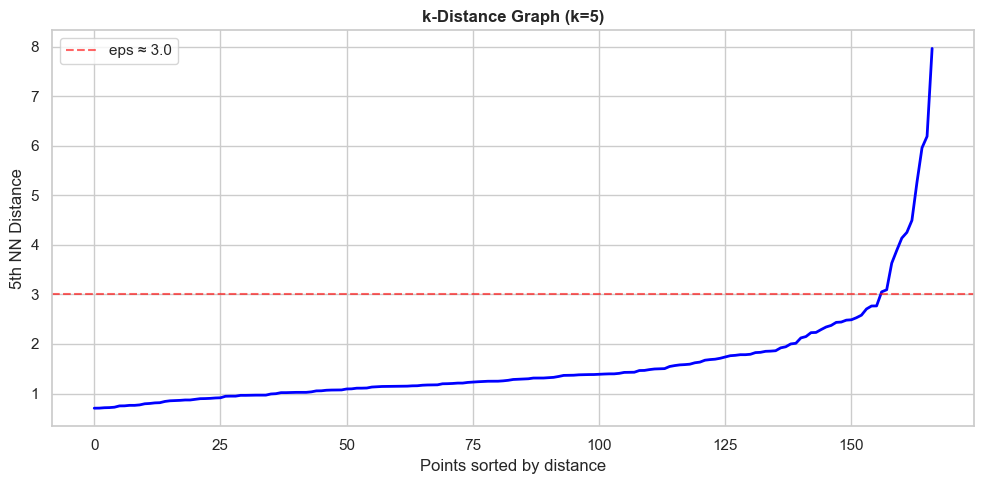

In [15]:
# k-distance graph to estimate eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist, 'b-', linewidth=2)
ax.set_title('k-Distance Graph (k=5)', fontweight='bold')
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel('5th NN Distance')
ax.axhline(y=3.0, color='red', linestyle='--', alpha=0.6, label='eps ≈ 3.0')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
dbscan = DBSCAN(eps=3.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN: {n_clusters_db} clusters, {n_noise} noise points")

mask = dbscan_labels != -1
if n_clusters_db > 1:
    print(f"  Silhouette Score: {silhouette_score(X_scaled[mask], dbscan_labels[mask]):.4f}")
    print(f"  Davies-Bouldin:   {davies_bouldin_score(X_scaled[mask], dbscan_labels[mask]):.4f}")

DBSCAN: 1 clusters, 8 noise points


### 7c. PCA Visualization

Explained variance: PC1=44.8%, PC2=15.7%


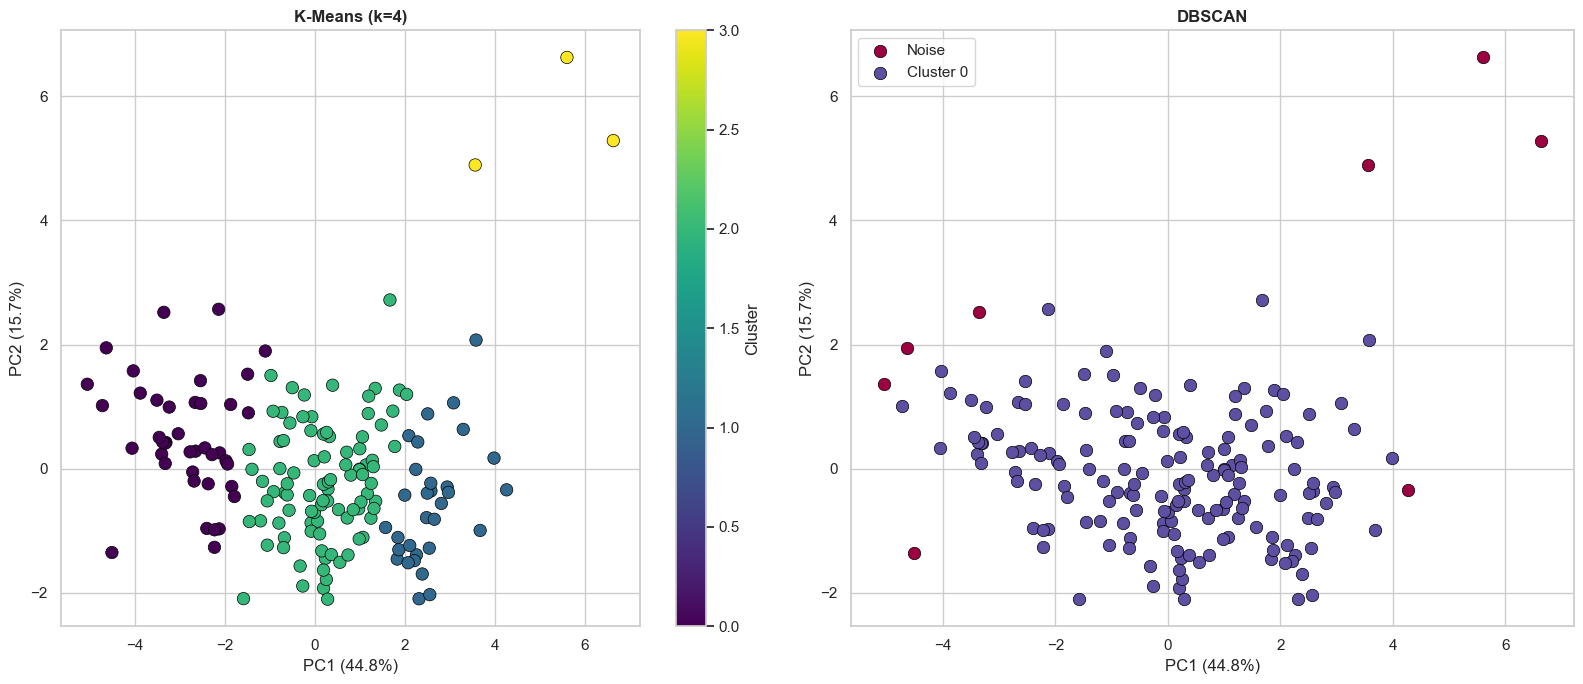

In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# K-Means
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                     cmap='viridis', s=80, edgecolors='k', linewidth=0.5)
axes[0].set_title(f'K-Means (k={optimal_k})', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(sc, ax=axes[0]).set_label('Cluster')

# DBSCAN
unique_labels = sorted(set(dbscan_labels))
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, colors):
    mask = dbscan_labels == label
    name = 'Noise' if label == -1 else f'Cluster {label}'
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color],
                    label=name, s=80, edgecolors='k', linewidth=0.5)
axes[1].set_title('DBSCAN', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Segment Profiling

In [18]:
df_seg = df.copy()
df_seg['Segment'] = kmeans_labels
df_seg['Development'] = y.values

profile = df_seg.groupby('Segment').agg({
    'child_mort': 'mean', 'exports': 'mean', 'health': 'mean',
    'imports': 'mean', 'income': 'mean', 'inflation': 'mean',
    'life_expec': 'mean', 'total_fer': 'mean', 'gdpp': 'mean',
    'country': 'count', 'Development': 'mean'
}).rename(columns={'country': 'Count', 'Development': 'Pct_Developed'}).round(2)

profile['Pct_Developed'] = (profile['Pct_Developed'] * 100).round(1)

def label_seg(row):
    if row['gdpp'] > 15000: return 'High-Income'
    elif row['gdpp'] > 5000: return 'Upper-Middle-Income'
    elif row['gdpp'] > 2000: return 'Lower-Middle-Income'
    else: return 'Low-Income'

profile['Label'] = profile.apply(label_seg, axis=1)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Count,Pct_Developed,Label
Segment,,,,,,,,,,,,
0,98.23,27.26,6.34,42.62,2913.49,12.29,58.97,5.23,1393.71,41,2.0,Low-Income
1,4.90,46.48,9.13,40.48,44703.23,2.61,80.28,1.79,42574.19,31,100.0,High-Income
2,23.90,41.07,6.25,47.37,12671.85,7.69,72.08,2.37,6688.83,92,53.0,Upper-Middle-Income
3,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67,3,100.0,High-Income


In [19]:
# Show countries in each segment
for seg in sorted(df_seg['Segment'].unique()):
    countries = df_seg[df_seg['Segment'] == seg]['country'].tolist()
    print(f"Segment {seg} ({profile.loc[seg, 'Label']}): {', '.join(countries)}")

Segment 0 (Low-Income): Afghanistan, Angola, Benin, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Kenya, Kiribati, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia
Segment 1 (High-Income): Australia, Austria, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Netherlands, New Zealand, Norway, Portugal, Qatar, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States
Segment 2 (Upper-Middle-Income): Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bahrain, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana, Braz

In [20]:
# Export
df_seg.to_csv(f'{OUTPUT_DIR}/country_segments.csv', index=False)
print(f"Exported: {OUTPUT_DIR}/country_segments.csv")

Exported: output/country_segments.csv


## 9. Correlation Heatmap

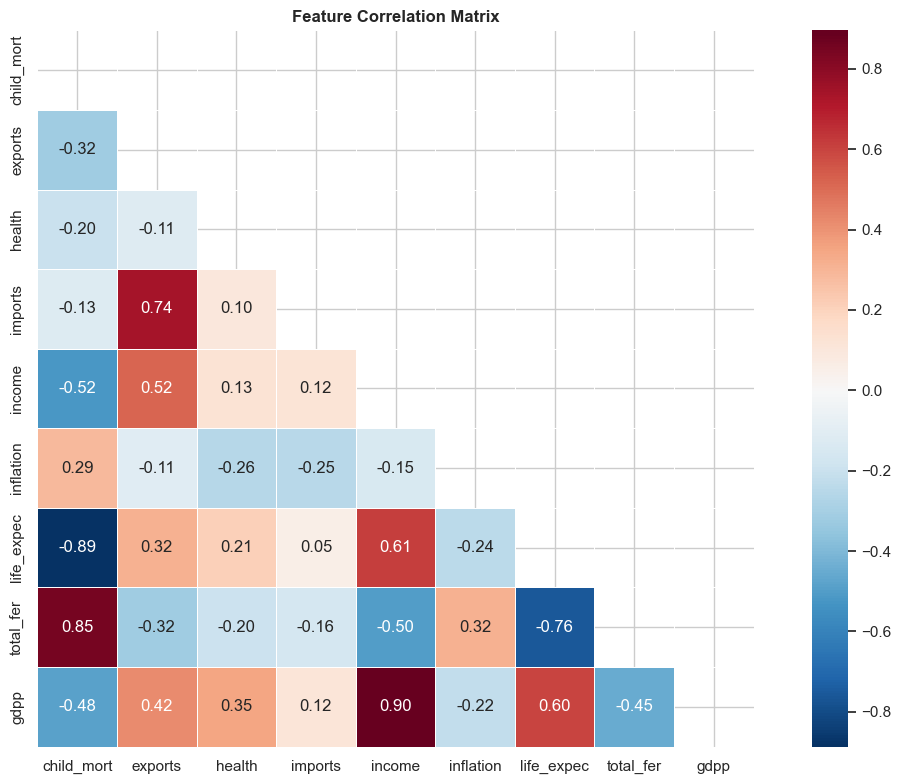

In [21]:
fig, ax = plt.subplots(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary

In [22]:
print("=" * 60)
print("  CUSTOMER INTELLIGENCE SYSTEM — RESULTS")
print("=" * 60)
print(f"  Classification: {len(models)} models compared")
print(f"  Best model:     {results_df.iloc[0]['Model']} (F1={results_df.iloc[0]['F1-Score']:.4f})")
print(f"  K-Means:        k={optimal_k}, Silhouette={sil:.4f}")
print(f"  DBSCAN:         {n_clusters_db} clusters, {n_noise} noise pts")
print(f"  Segments:       {optimal_k} country segments profiled")
print(f"  Outputs:        {OUTPUT_DIR}/")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"    └─ {f}")
print("=" * 60)

  CUSTOMER INTELLIGENCE SYSTEM — RESULTS
  Classification: 4 models compared
  Best model:     Random Forest (F1=1.0000)
  K-Means:        k=4, Silhouette=0.2951
  DBSCAN:         1 clusters, 8 noise pts
  Segments:       4 country segments profiled
  Outputs:        output/
    └─ clustering_pca.png
    └─ correlation_heatmap.png
    └─ country_segments.csv
    └─ dbscan_kdist.png
    └─ feature_importance.png
    └─ kmeans_elbow.png
    └─ roc_curves.png
